<h4><b>Redes Neurais Artificiais</b></h4>
<p>Cross-validation</p>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [4]:
path = '/media/marcos/500GB/00_datasets/post_processing/post_processing_dataset.csv'
df = pd.read_csv(path)

In [6]:
df = df[[
    'line_category',
    'line_color',
    'station_initial_latitude',
    'station_initial_longitude',
    'station_final_latitude',
    'station_final_longitude',
    'distance',
    'average_speed_kh',
    'duration'
]]

In [7]:
X = df.iloc[:,0:8].values
y = df.iloc[:,8].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

regressor_rna = MLPRegressor(max_iter=500, hidden_layer_sizes=(4,4), random_state=0)

cv = KFold(n_splits=5, shuffle=True, random_state=0)

In [8]:
def mae_inversed(estimator, X, y):
    y_pred_scaled = estimator.predict(X)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y.reshape(-1, 1)).ravel()
    return mean_absolute_error(y_true, y_pred)

mae_scores_train = cross_val_score(regressor_rna, X_train_scaled, y_train_scaled, cv=cv, scoring=mae_inversed)

In [9]:
regressor_rna.fit(X_train_scaled, y_train_scaled)

MLPRegressor(hidden_layer_sizes=(4, 4), max_iter=500, random_state=0)

In [10]:
y_train_pred_scaled = regressor_rna.predict(X_train_scaled)
y_test_pred_scaled = regressor_rna.predict(X_test_scaled)

In [11]:
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

In [13]:
# Definindo as listas para armazenar as métricas
mae_scores_train = []
mse_scores_train = []
rmse_scores_train = []
mae_scores_test = []
mse_scores_test = []
rmse_scores_test = []

# Calculando as métricas para a Cross-Validation do conjunto de treino
for train_idx, val_idx in cv.split(X_train_scaled, y_train_scaled):
    X_val, y_val = X_train_scaled[val_idx], y_train_scaled[val_idx]
    
    y_val_pred_scaled = regressor_rna.predict(X_val)
    y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).ravel()
    y_val_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()

    mae_scores_train.append(mean_absolute_error(y_val_true, y_val_pred))
    mse_scores_train.append(mean_squared_error(y_val_true, y_val_pred))
    rmse_scores_train.append(np.sqrt(mse_scores_train[-1]))

# Calculando as métricas para o conjunto de teste
for train_idx, val_idx in cv.split(X_test_scaled, y_test_scaled):
    X_val, y_val = X_test_scaled[val_idx], y_test_scaled[val_idx]

    y_val_pred_scaled = regressor_rna.predict(X_val)
    y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).ravel()
    y_val_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()

    mae_scores_test.append(mean_absolute_error(y_val_true, y_val_pred))
    mse_scores_test.append(mean_squared_error(y_val_true, y_val_pred))
    rmse_scores_test.append(np.sqrt(mse_scores_test[-1]))

# Treinando o modelo final
regressor_rna.fit(X_train_scaled, y_train_scaled)

# Fazendo previsões
y_train_pred_scaled = regressor_rna.predict(X_train_scaled)
y_test_pred_scaled = regressor_rna.predict(X_test_scaled)

# Convertendo de volta para a escala original
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

# Calculando métricas finais
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Calculando desvios padrão corretamente
mae_train_std = np.std(mae_scores_train)
mse_train_std = np.std(mse_scores_train)
rmse_train_std = np.std(rmse_scores_train)

mae_test_std = np.std(mae_scores_test)
mse_test_std = np.std(mse_scores_test)
rmse_test_std = np.std(rmse_scores_test)

# Exibindo os resultados
print("MAE para cada fold na Cross-Validation (dados de treino):")
for i, score in enumerate(mae_scores_train, 1):
    print(f"Fold {i}: {score:.4f}")
print('-' * 60)
print(f"MAE treino: {np.mean(mae_scores_train):.4f} ± {mae_train_std:.4f}")

print("\nMAE para cada fold na Cross-Validation (dados de teste):")
for i, score in enumerate(mae_scores_test, 1):
    print(f"Fold {i}: {score:.4f}")
print('-' * 60)
print(f"MAE teste: {np.mean(mae_scores_test):.4f} ± {mae_test_std:.4f}")
print('-' * 60)
print(f"MSE treino: {mse_train:.4f} ± {mse_train_std:.4f}")
print(f"MSE teste: {mse_test:.4f} ± {mse_test_std:.4f}")
print('-' * 60)
print(f"RMSE treino: {rmse_train:.4f} ± {rmse_train_std:.4f}")
print(f"RMSE teste: {rmse_test:.4f} ± {rmse_test_std:.4f}")
print('-' * 60)
print(f"R² treino: {r2_train:.4f}")
print(f"R² teste: {r2_test:.4f}")

MAE para cada fold na Cross-Validation (dados de treino):
Fold 1: 45.5053
Fold 2: 45.9871
Fold 3: 47.0354
Fold 4: 45.0195
Fold 5: 45.0581
------------------------------------------------------------
MAE treino: 45.7211 ± 0.7452

MAE para cada fold na Cross-Validation (dados de teste):
Fold 1: 44.8708
Fold 2: 43.7334
Fold 3: 44.2410
Fold 4: 41.0894
Fold 5: 43.9323
------------------------------------------------------------
MAE teste: 43.5734 ± 1.3003
------------------------------------------------------------
MSE treino: 4033.1907 ± 206.9525
MSE teste: 3763.8852 ± 450.7940
------------------------------------------------------------
RMSE treino: 63.5074 ± 1.6163
RMSE teste: 61.3505 ± 3.7029
------------------------------------------------------------
R² treino: 0.9864
R² teste: 0.9870


In [16]:
train_sizes, train_scores, test_scores = learning_curve(
    regressor_rna,                  # Modelo SVR
    X_train,                     # Dados de entrada
    y_train.ravel(),             # Rótulos (vetor)
    cv=5,                               # Número de folds na validação cruzada
    scoring='neg_mean_absolute_error',   # Métrica de avaliação
    n_jobs=-1,                          # Paralelização
    train_sizes=np.linspace(0.1, 1.0, 10)  # Frações do conjunto de treinamento
)

/home/marcos/anaconda3/envs/pln_env_v_01/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/marcos/anaconda3/envs/pln_env_v_01/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/marcos/anaconda3/envs/pln_env_v_01/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/marcos/anaconda3/envs/pln_env_v_01/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization has

In [17]:
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

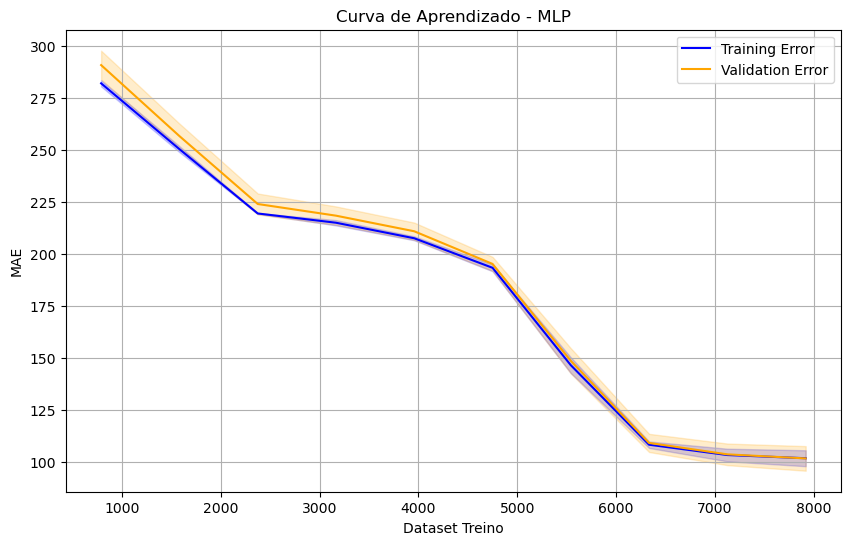

In [18]:
plt.figure(figsize=(10, 6))

# Plotar a média do erro no conjunto de treino
plt.plot(train_sizes, train_mean, label="Training Error", color="blue")

# Adicionar faixa de desvio padrão
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)

# Plotar a média do erro no conjunto de validação
plt.plot(train_sizes, test_mean, label="Validation Error", color="orange")

# Adicionar faixa de desvio padrão
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="orange", alpha=0.2)

# Detalhes do gráfico
plt.title("Curva de Aprendizado - MLP")
plt.xlabel("Dataset Treino")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid()
plt.savefig('mlp_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()